In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data import *
from data_utils import len_active_terms, f_active_terms
from information_content import deprecated

Correspondances trouvées : 550


/home/onyxia/work/OT_simulation_maladies/Embeddings/data.py:72: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  profils_omim = profils_omim.reset_index()


# Statistiques descriptives sur l'arbre HPO

<Axes: >

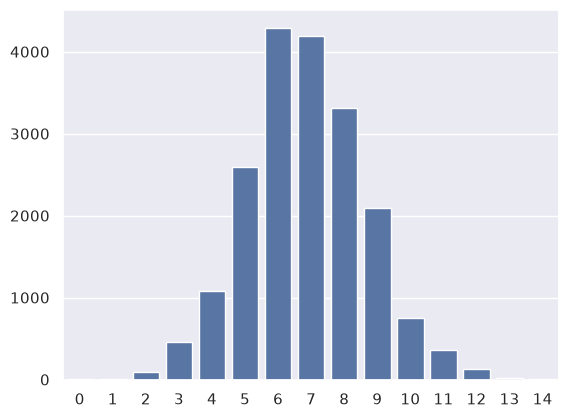

In [11]:
n_nodes = G_hpo_work.number_of_nodes()
n_edges = G_hpo_work.number_of_edges()

prof = [v for v in depths.values()]
x,y = np.unique(prof, return_counts=True)
sns.set_theme()
sns.barplot(x=x,y=y)

In [30]:
import pandas as pd
out_deg = [v for v in dict(G_hpo_work.in_degree()).values()]
print(np.mean(out_deg), np.max(out_deg), np.min(out_deg), np.std(out_deg))
df = pd.read_csv("../data/HPOs.csv", sep=";")

1.2210819452323243 193 0 3.375027598225367


In [43]:
df_orpha_omim["mapping_type"].unique()

<ArrowStringArray>
[                                                    'E (Exact mapping: the two concepts are equivalent)',
                                'BTNT (ORPHAcode is broader than the targeted code used to represent it)',
                               'NTBT (ORPHAcode is narrower than the targeted code used to represent it)',
 'ND (not yet decided/unable to decide: the alignment cannot be qualified by any of the existing labels)']
Length: 4, dtype: str

# Statistiques descriptives sur les maladies hpoa

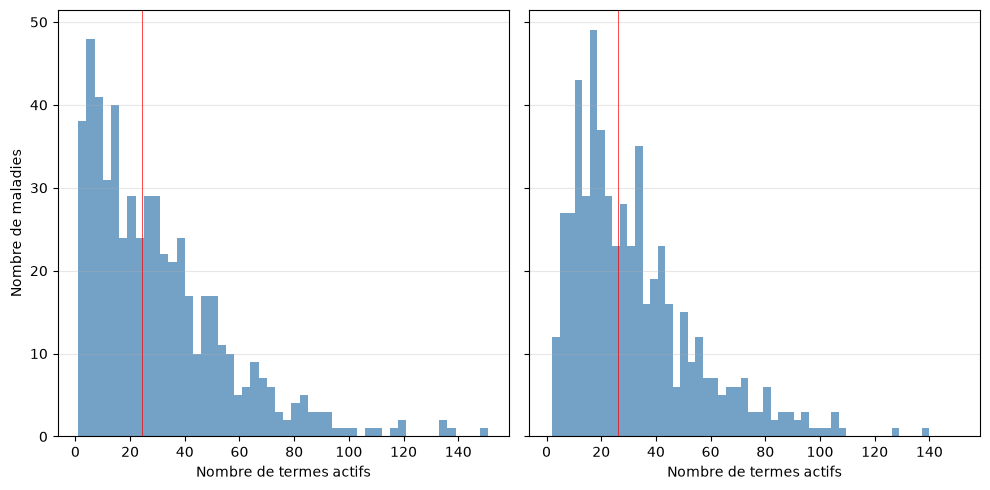

In [3]:
# Nombre moyen de termes hpo par maladie
df_omim['active terms']=df_omim.apply(len_active_terms, axis=1, args=(hpo_cols, node2id_w, deprecated))
df_orpha["active terms"]=df_orpha.apply(len_active_terms, axis=1, args=(hpo_cols, node2id_w, deprecated))

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

ax = axes[0]
sns.histplot(df_omim['active terms'], bins=50, ax=ax, color='steelblue', edgecolor='none')

ax.axvline(np.median(df_omim['active terms']), color='r', lw=0.5)
ax.set_xlabel("Nombre de termes actifs")
ax.set_ylabel("Nombre de maladies")
#ax.set_title(f"Omim (nombre median : {np.median(df_omim['active terms']).round(0)})")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(df_orpha['active terms'], bins=50, ax=ax, color='steelblue', edgecolor='none')

ax.axvline(np.median(df_orpha['active terms']), color='r', lw=0.5)
ax.set_xlabel("Nombre de termes actifs")
ax.set_ylabel("Nombre de maladies")
#ax.set_title(f"Orpha (nombre median : {np.median(df_orpha['active terms']).round(0)})")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

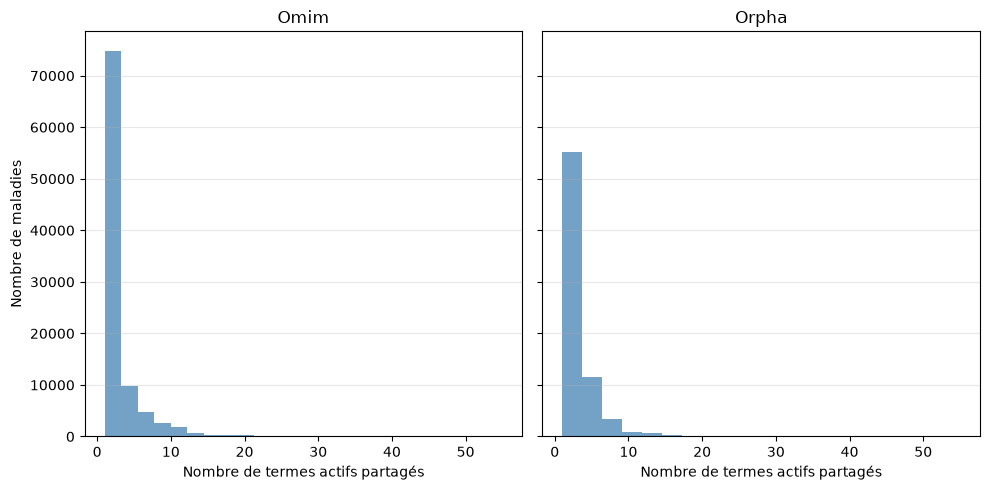

In [5]:
# Nombre de termes HPO partagés entre maladies 
df_omim['list active terms']=df_omim.apply(f_active_terms, axis=1, args=(hpo_cols, node2id_w, deprecated))
df_orpha['list active terms']=df_orpha.apply(f_active_terms, axis=1, args=(hpo_cols, node2id_w, deprecated))

def shared_active_terms_intra(df):
    df_reset = df.reset_index(drop=True)
    n = df_reset.shape[0]
    
    all_terms = sorted(set(t for terms in df_reset['list active terms'] for t in terms))
    term_to_idx = {t: i for i, t in enumerate(all_terms)}
    p = len(all_terms)

    M = np.zeros((n, p), dtype=np.float32)
    for i, row in df_reset.iterrows():
        for t in row['list active terms']:
            M[i, term_to_idx[t]] = 1.0
    
    shared = (M @ M.T).astype(np.float32)
    np.fill_diagonal(shared, df_reset['active terms'].values)
    
    idx = np.tril_indices(n, k=-1)
    return shared, shared[idx], np.mean(shared[idx])


shared_matrix_omim, shared_omim, mean_shared_omim = shared_active_terms_intra(df_omim)
shared_matrix_orpha, shared_orpha, mean_shared_orpha = shared_active_terms_intra(df_orpha)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

ax = axes[0]
sns.histplot(shared_omim[shared_omim!=0], bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Nombre de termes actifs partagés")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Omim")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(shared_orpha[shared_orpha!=0], bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Nombre de termes actifs partagés")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Orpha")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
print("Termes partagés : OMIM")
print(f"Max : {np.max(shared_omim)}")
print(f"Moyenne : {mean_shared_omim.round(2)}")
print(f"Pourcentage de paires sans terme commun : {np.round(len(shared_omim[shared_omim==0])/(len(shared_omim))*100, 2)}%")
print(f"Pourcentage de paires avec au moins deux termes communs : {np.round(len(shared_omim[shared_omim>1])/(len(shared_omim))*100, 2)}%")
print("Termes partagés : ORPHA")
print(f"Max : {np.max(shared_orpha)}")
print(f"Moyenne : {mean_shared_orpha.round(2)}")
print(f"Pourcentage de paires sans terme commun : {np.round(len(shared_orpha[shared_orpha==0])/(len(shared_orpha))*100, 2)}%")
print(f"Pourcentage de paires avec au moins deux termes communs : {np.round(len(shared_orpha[shared_orpha>1])/(len(shared_orpha))*100, 2)}%")

Termes partagés : OMIM
Max : 46.0
Moyenne : 1.6799999475479126
Pourcentage de paires sans terme commun : 36.76%
Pourcentage de paires avec au moins deux termes communs : 31.02%
Termes partagés : ORPHA
Max : 55.0
Moyenne : 1.2799999713897705
Pourcentage de paires sans terme commun : 52.42%
Pourcentage de paires avec au moins deux termes communs : 27.6%


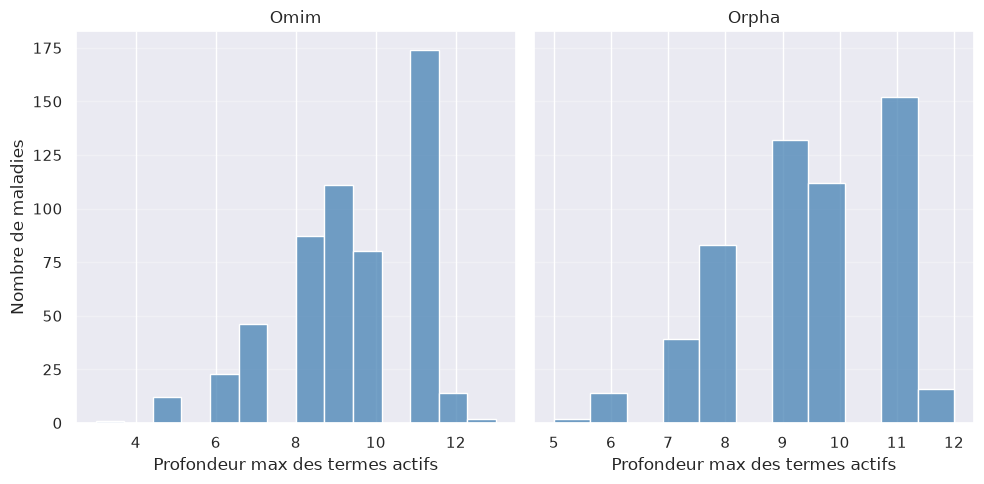

In [10]:
# Distribution de la profondeur maximale des termes pour les maladies
def depths_active_terms(df, depths):
    df_reset = df.reset_index(drop=True)
    n = df_reset.shape[0]
    
    all_terms = sorted(set(t for terms in df_reset['list active terms'] for t in terms))
    term_to_idx = {t: i for i, t in enumerate(all_terms)}
    p = len(all_terms)
    M = np.zeros((n, p), dtype=np.float32)
    for i, row in df_reset.iterrows():
        for t in row['list active terms']:
            M[i, term_to_idx[t]] = depths[t]
    return M

depths_omim = depths_active_terms(df_omim, depths)
depths_orpha = depths_active_terms(df_orpha, depths)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
sns.set_theme()
ax = axes[0]
sns.histplot(np.array([np.max(row[row != 0]) for row in depths_omim]), ax=ax, color='steelblue')

ax.set_xlabel("Profondeur max des termes actifs")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Omim")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(np.array([np.max(row[row != 0]) for row in depths_orpha]), ax=ax, color='steelblue')

ax.set_xlabel("Profondeur max des termes actifs")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Orpha")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

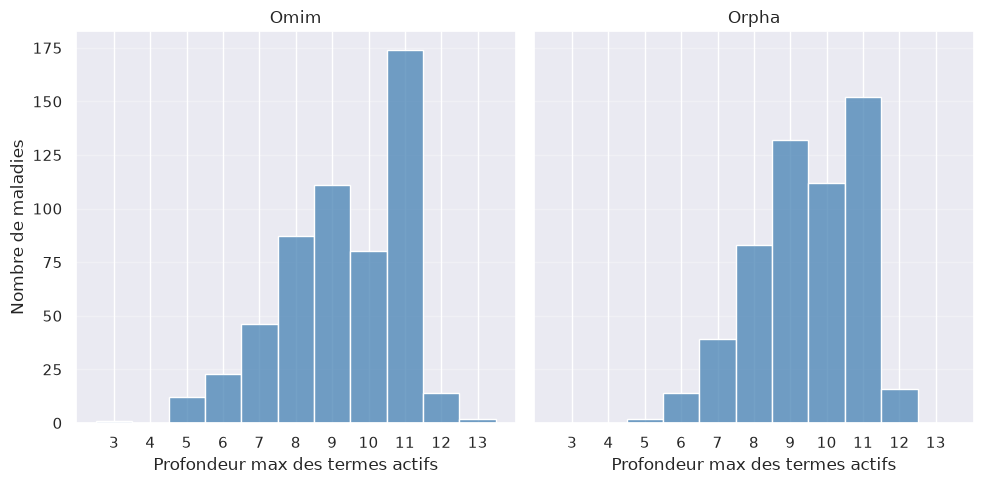

In [13]:
data_omim = np.array([np.max(row[row != 0]) for row in depths_omim])
data_orpha = np.array([np.max(row[row != 0]) for row in depths_orpha])

vmin = min(data_omim.min(), data_orpha.min())
vmax = max(data_omim.max(), data_orpha.max())

# bins centrés sur les entiers
bin_edges = np.arange(vmin, vmax + 2) - 0.5
bin_centers = np.arange(vmin, vmax + 1)  # = centres des bins = valeurs entières

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
sns.set_theme()

for ax, data, title in zip(axes, [data_omim, data_orpha], ["Omim", "Orpha"]):
    sns.histplot(data, ax=ax, color='steelblue', bins=bin_edges)
    ax.set_xlabel("Profondeur max des termes actifs")
    ax.set_ylabel("Nombre de maladies")
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticks(bin_centers)  # <-- force une graduation par bin/valeur entière

plt.tight_layout()
plt.show()

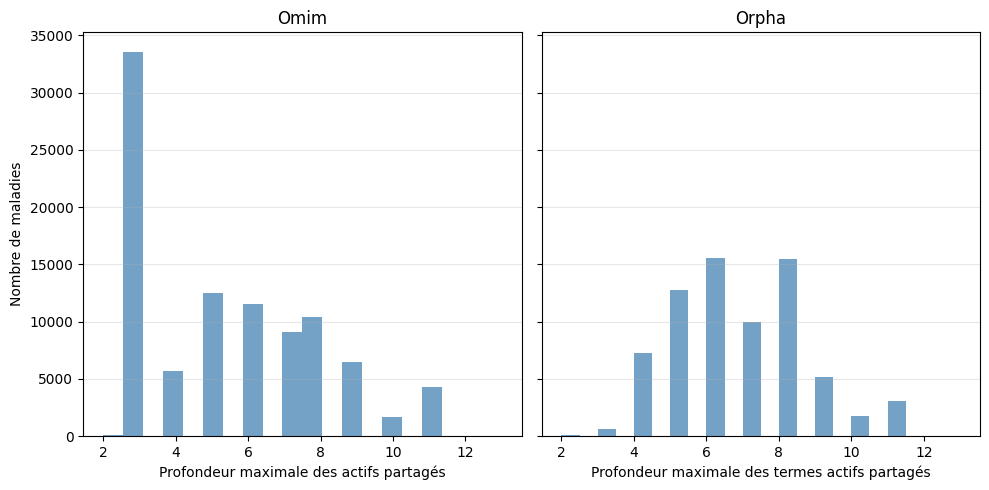

In [6]:
def max_depth_shared_terms(df, depths):
    df_reset = df.reset_index(drop=True)
    n = df_reset.shape[0]
    
    all_terms = sorted(depths.keys())
    term_to_idx = {t: i for i, t in enumerate(all_terms)}
    p = len(all_terms)
    
    # Matrice binaire (n x p)
    M = np.zeros((n, p), dtype=np.float32)
    D = np.zeros(p, dtype=np.float32)  # vecteur des profondeurs
    for i, row in df_reset.iterrows():
        for t in row['list active terms']:
            if t in term_to_idx:
                M[i, term_to_idx[t]] = 1.0
                D[term_to_idx[t]] = depths[t]
    rows, cols = np.tril_indices(n, k=-1)
    max_depths = np.array([
        np.max(D * M[rows[k]] * M[cols[k]]) if np.any(M[rows[k]] * M[cols[k]]) else 0.0
        for k in range(len(rows))
    ])
    return max_depths

max_shared_depths_omim = max_depth_shared_terms(df_omim, depths)
max_shared_depths_orpha = max_depth_shared_terms(df_orpha, depths)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

ax = axes[0]
sns.histplot(max_shared_depths_omim[max_shared_depths_omim!=0], bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Profondeur maximale des actifs partagés")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Omim")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.histplot(max_shared_depths_orpha[max_shared_depths_orpha!=0], bins=20, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel("Profondeur maximale des termes actifs partagés")
ax.set_ylabel("Nombre de maladies")
ax.set_title("Orpha")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
print("Profils OMIM")
print(f"Paires partageant des termes de profondeur au moins 4 : {np.round(len(max_shared_depths_omim[max_shared_depths_omim>3])/len(max_shared_depths_omim)*100, 2)}%")
print("Profils ORPHA")
print(f"Paires partageant des termes de profondeur au moins 4 : {np.round(len(max_shared_depths_orpha[max_shared_depths_orpha>3])/len(max_shared_depths_orpha)*100, 2)}%")

Profils OMIM
Paires partageant des termes de profondeur au moins 4 : 40.92%
Profils ORPHA
Paires partageant des termes de profondeur au moins 4 : 47.13%


In [7]:
def shared_active_terms_inter(df_omim, df_orpha):
    def get_active_matrix(df, all_terms):
        df_reset = df.reset_index(drop=True)
        n = df_reset.shape[0]
    
        #all_terms = sorted(set(t for terms in df_reset['list active terms'] for t in terms))
        term_to_idx = {t: i for i, t in enumerate(all_terms)}
        p = len(all_terms)

        M = np.zeros((n, p), dtype=np.float32)
        for i, row in df_reset.iterrows():
            for t in row['list active terms']:
                M[i, term_to_idx[t]] = 1.0
        return M, term_to_idx
    all_terms = sorted(set(
        t for df in [df_omim.reset_index(drop=True), df_orpha.reset_index(drop=True)] 
        for terms in df['list active terms'] for t in terms))
    M0, t2id = get_active_matrix(df_omim, all_terms)
    M1, _ = get_active_matrix(df_orpha, all_terms)
    print(M0.shape)
    print(M1.shape)
    
    shared = (M0 @ M1.T).astype(np.float32)
    return shared, t2id

shared_matrix_inter, t2id = shared_active_terms_inter(df_omim, df_orpha)

(550, 5291)
(550, 5291)


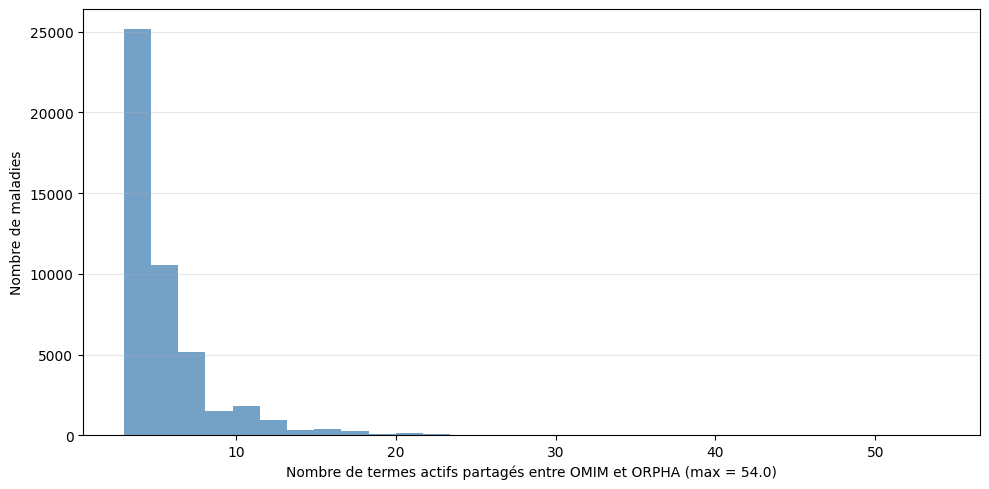

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

ax 
sns.histplot(shared_matrix_inter[shared_matrix_inter > 2].ravel(), bins=30, ax=ax, color='steelblue', edgecolor='none')

ax.set_xlabel(f"Nombre de termes actifs partagés entre OMIM et ORPHA (max = {np.max(shared_matrix_inter)})")
ax.set_ylabel("Nombre de maladies")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print(np.round(np.mean(shared_matrix_inter, axis=1), 2))
for i in range(shared_matrix_inter.shape[0]):
    print(f"Nombres de termes actifs partagés >3 : {shared_matrix_inter[shared_matrix_inter>3][i].sum()}/550")
# Ecart type pour chaque maladie OMIM (rapporté à la moyenne)
print(np.std(shared_matrix_inter, axis=1)/np.mean(shared_matrix_inter, axis=1))

Text(0, 0.5, 'Nb de maladies avec au moins k termes en commun')

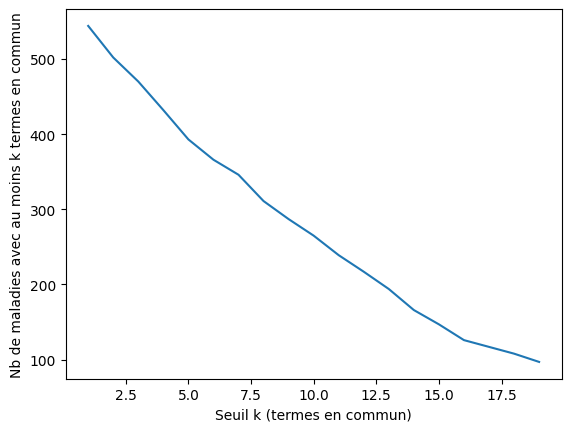

In [9]:
thresholds = range(1, 20)
results = []

for k in thresholds:
    adjacency = shared_matrix_inter >= k
    n = (adjacency.sum(axis=1) > 0).sum()
    results.append(n)

plt.plot(thresholds, results)
plt.xlabel("Seuil k (termes en commun)")
plt.ylabel("Nb de maladies avec au moins k termes en commun")

Nb de composantes : 151
Taille max : 385
Entrées isolées : 137


<Axes: >

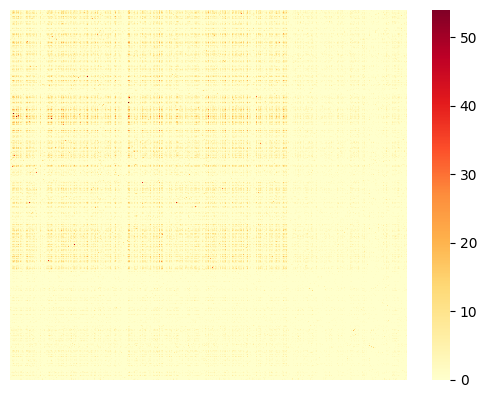

In [19]:
from scipy.sparse.csgraph import connected_components
from scipy.sparse import csr_matrix

k = 10
adjacency = (shared_matrix_inter >= k).astype(np.float32)

n_components, labels = connected_components(csr_matrix(adjacency), directed=False)
sizes = np.bincount(labels)

print(f"Nb de composantes : {n_components}")
print(f"Taille max : {sizes.max()}")
print(f"Entrées isolées : {(sizes == 1).sum()}")

order = np.argsort(labels)
sorted_matrix = shared_matrix_inter[np.ix_(order, order)]
sns.heatmap(sorted_matrix, cmap="YlOrRd", xticklabels=False, yticklabels=False)